In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModel


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.metrics import(
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')


 Imports OK
   torch   2.10.0+cu128
   device  cpu


In [3]:
BIOBERT_MODEL = 'dmis-lab/biobert-base-cased-v1.2'
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
biobert = AutoModel.from_pretrained(BIOBERT_MODEL).to(DEVICE)
biobert.eval()

print(f'Loaded BioBERT model: {BIOBERT_MODEL}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BioBERT model: dmis-lab/biobert-base-cased-v1.2


In [4]:
def extract_biobert_embeddings(
        texts, tokenizer, model, device, batch_size=16, 
        max_length=512, pooling = 'cls'
):
    all_embeddings = []
    n = len(texts)
    print(f'Extracting BioBERT embeddings for {n} texts...')

    for i in range(0, n, batch_size):
        end =  min(i + batch_size, n)
        batch = list(texts[i:end])
        encodings  = tokenizer(
            batch,
            padding = True,
            truncation = True,
            max_length = max_length,
            return_tensors = 'pt'
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            outputs = model(**encodings)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(batch_embeddings)
        print(f'  Processed {end}/{n} texts', end='\r')
    print('\nDone.')
    result = np.vstack(all_embeddings)
    print(f'Extracted embeddings shape: {result.shape}')
    return result

In [5]:
CSV_PATH = Path('full_data/claims.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: mumin_claims_cardio_diabete_baseline_ready.csv\n'
        'Run NB1 first to generate it.'
    )

In [6]:
df = pd.read_csv(CSV_PATH)
print(f' Dataset loaded: {len(df)} claims')
df.shape
df.head()


 Dataset loaded: 3423 claims


,id,name,statement,description,category,rating,queries,created_at,updated_at
0,6771,NaN,Dawn dish soap contains ammonia even though it...,Could Mixing Dawn Dish Soap with Clorox Bleach...,"{medical,science}",mixture,NaN,2020-06-28 21:40:18.799231+02,2020-06-28 21:40:18.799231+02
1,799,NaN,Do probiotics help with Irritable Bowel Syndrome?,NaN,{medical},true,NaN,2019-12-13 14:27:18.231183+01,2022-01-28 12:01:30.203904+01
2,2468,NaN,Is blue light harmful to our eyes?,<p>It seems reasonable to reduce exposure to b...,{medical},unknown,NaN,2019-12-13 14:31:00.722277+01,2022-02-04 12:13:34.253699+01
3,2634,NaN,Does caffeine help asthma sufferers?,"<p><a href=""https://www.nytimes.com/2010/11/30...",{medical},unknown,NaN,2019-12-13 14:31:25.271774+01,2022-01-28 12:01:22.380887+01
4,2745,NaN,Is there a link between diet and vasculitis?,NaN,{medical},unknown,NaN,2019-12-13 14:31:40.382026+01,2022-02-03 12:08:42.081948+01


In [7]:
df['text'] = (
    df['name'].fillna('').astype(str) + ' ' +
    df['statement'].fillna('').astype(str) + ' ' +
    df['description'].fillna('').astype(str)
)

In [34]:
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}

valid_ratings = set(rating_aliases)
df = df[df['rating'].isin(valid_ratings)].copy()
df = df[['id', 'text', 'rating']].reset_index(drop=True)

In [35]:
df.shape


(1341, 3)

In [36]:
EMBED_CACHE = 'biobert_embeddings.npy'

if Path(EMBED_CACHE).exists():
    X = np.load(EMBED_CACHE)
    if X.shape[0] != len(df):
        print(
            f'Embedding cache shape mismatch: {X.shape[0]} rows loaded, but df has {len(df)} rows. '
            'Recomputing embeddings...'
        )
        X = extract_biobert_embeddings(
            texts = df['text'].values,
            tokenizer = tokenizer,
            model = biobert,
            device = DEVICE,
            batch_size = 16,
            max_length = 512,
            pooling = 'cls'
        )
        np.save(EMBED_CACHE, X)
        print(f'Cached embeddings saved to {EMBED_CACHE}')
    else:
        print(f'Loaded cached embeddings from {EMBED_CACHE}...')
        print(f'Loaded embeddings shape: {X.shape}')
else:
    X = extract_biobert_embeddings(
        texts = df['text'].values,
        tokenizer = tokenizer,
        model = biobert,
        device = DEVICE,
        batch_size = 16,
        max_length = 512,
        pooling = 'cls'
    )
    np.save(EMBED_CACHE, X)
    print("It can take a while to extract embeddings for all claims. Please be patient.")
    print(f'Cached embeddings saved to {EMBED_CACHE}')


Loaded cached embeddings from biobert_embeddings.npy...
Loaded embeddings shape: (1341, 768)


This cell computes a topic relevance score for each claim in `df` using BioBERT embeddings.

1. It imports `cosine_similarity` to compare claim embeddings with query embeddings.
2. It defines a list of medical query phrases describing cardiovascular and diabetes topics.
3. It creates embeddings for these queries using the same BioBERT model.
4. It computes a `topic_score` for each claim by taking the maximum cosine similarity between the claim embedding and any query embedding.
5. It selects only claims with a score above the threshold `SEUIL_STRICT = 0.80` and sorts them by relevance.
6. Finally, it prints how many claims were selected and shows the top results.

In [57]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

import torch

queries = [
    "cardiovascular disease", "cardiovascular disorders", "heart disease", "cardiac disease", "coronary artery disease", "coronary heart disease", "ischemic heart disease", "myocardial ischemia", "myocardial infarction", "heart attack", "acute coronary syndrome", "stroke", "ischemic stroke", "hemorrhagic stroke", "cerebrovascular accident", "transient ischemic attack", "tia", "hypertension", "high blood pressure", "arterial hypertension", "heart failure", "congestive heart failure", "arrhythmia", "atrial fibrillation", "ventricular arrhythmia",
    "chest pain", "angina", "stable angina", "unstable angina", "shortness of breath", "dyspnea", "exertional dyspnea", "palpitations", "tachycardia", "bradycardia", "fatigue", "chronic fatigue", "exercise intolerance", "dizziness", "vertigo", "lightheadedness", "syncope", "fainting", "loss of consciousness", "edema", "peripheral edema", "swelling",
    "smoking", "tobacco use", "nicotine exposure", "obesity", "overweight", "bmi", "body mass index", "high cholesterol", "hyperlipidemia", "ldl", "hdl", "triglycerides", "diabetes", "insulin resistance", "sedentary lifestyle", "physical inactivity", "family history", "genetic predisposition", "age", "male sex", "stress", "poor diet",
    "statins", "beta-blockers", "ace inhibitors", "arbs", "antihypertensive drugs", "anticoagulants", "blood thinners", "aspirin therapy", "antiplatelet therapy", "angioplasty", "percutaneous coronary intervention", "stent", "coronary stent", "bypass surgery", "coronary artery bypass graft", "cardiac rehabilitation",
    "ecg", "electrocardiogram", "ekg", "blood pressure", "ambulatory blood pressure monitoring", "cholesterol levels", "lipid panel", "troponin", "cardiac biomarkers", "echocardiogram", "cardiac ultrasound", "stress test", "exercise tolerance test", "ct angiography",
    "type 1 diabetes", "type 2 diabetes", "gestational diabetes", "prediabetes", "latent autoimmune diabetes", "lada", "mody", "maturity onset diabetes of the young",
    "frequent urination", "polyuria", "excessive thirst", "polydipsia", "polyphagia", "increased appetite", "weight loss", "unexplained weight loss", "blurred vision", "slow wound healing", "fatigue", "lethargy",
    "insulin", "insulin therapy", "metformin", "oral hypoglycemics", "glucose-lowering drugs", "sulfonylureas", "glp-1 agonists", "sglt2 inhibitors", "lifestyle intervention", "diet control", "carbohydrate counting", "continuous glucose monitoring", "cgm",
    "blood glucose", "blood sugar", "fasting glucose", "postprandial glucose", "hba1c", "glycated hemoglobin", "insulin level", "glucose tolerance test", "ogtt", "c-peptide",
    "neuropathy", "diabetic neuropathy", "nephropathy", "kidney disease", "retinopathy", "diabetic retinopathy", "diabetic foot ulcer", "cardiovascular complications", "macrovascular complications", "microvascular complications"
]

def embed_queries(queries, tokenizer, model, device):
    model.eval()
    enc = tokenizer(queries, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        return model(**enc).last_hidden_state[:, 0, :].cpu().numpy()


q_emb = embed_queries(queries, tokenizer, biobert, DEVICE)
df['topic_score'] = cosine_similarity(X, q_emb).max(axis=1)


SEUIL_STRICT = 0.80

selected_df = df[df['topic_score'] >= SEUIL_STRICT].sort_values('topic_score', ascending=False).copy()
X_selected = X[selected_df.index.to_numpy()]
y = selected_df['rating'].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f'Selected {len(selected_df)} rows')
selected_df.to_csv('monant_filtered_biobert.csv', index=False)
selected_df.head(10)

Selected 733 rows


,id,text,rating,topic_score
387,5354,Essiac essiac treat cancer,false,0.929142
334,5310,Screening for breast cancer with mammography (...,false,0.918953
340,5330,Cancer guided imagery guided imagery treat can...,false,0.918150
375,5342,Contreras therapy (contreras therapy|Metabolic...,false,0.916100
376,5344,"Craniosacral therapy , CST (Craniosacral|Crani...",false,0.915018
371,5338,Chlorella chlorella treat cancer,false,0.914138
406,5373,Insulin potentiation therapy (Insulin therapy|...,false,0.914015
420,5388,Meditation (Meditation|Mindfulness|meditating...,false,0.913056
369,5327,Budwig protocol budwig treat cancer,false,0.912186
429,5397,Naturopathy (natureopathy|naturopathic|natureo...,false,0.911208


In [21]:
# Use the selected subset for downstream classification
# so the models train and evaluate only on relevant claims.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

In [44]:
# ── Classifiers on top of BioBERT embeddings

clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])

biobert_models = {
    'BioBERT + LR':      clf_lr,
    'BioBERT + LinearSVC': clf_svm,
    'BioBERT + MLP':     clf_mlp,
}

for name in biobert_models:
    print(f'   • {name}')


   • BioBERT + LR
   • BioBERT + LinearSVC
   • BioBERT + MLP


In [45]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_bb = {}

for name, clf in biobert_models.items():
    cv = cross_validate(
        clf, X_selected, y_encoded,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_bb[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()


── BioBERT + LR ──
  Accuracy  : 0.8499 ± 0.0262
  F1 macro  : 0.6663 ± 0.1387
  Precision : 0.6897 ± 0.1485
  Recall    : 0.6572 ± 0.1396

── BioBERT + LinearSVC ──
  Accuracy  : 0.8322 ± 0.0221
  F1 macro  : 0.6240 ± 0.0953
  Precision : 0.6596 ± 0.1389
  Recall    : 0.6169 ± 0.0855

── BioBERT + MLP ──
  Accuracy  : 0.8731 ± 0.0315
  F1 macro  : 0.5883 ± 0.1113
  Precision : 0.6199 ± 0.1451
  Recall    : 0.5801 ± 0.1047



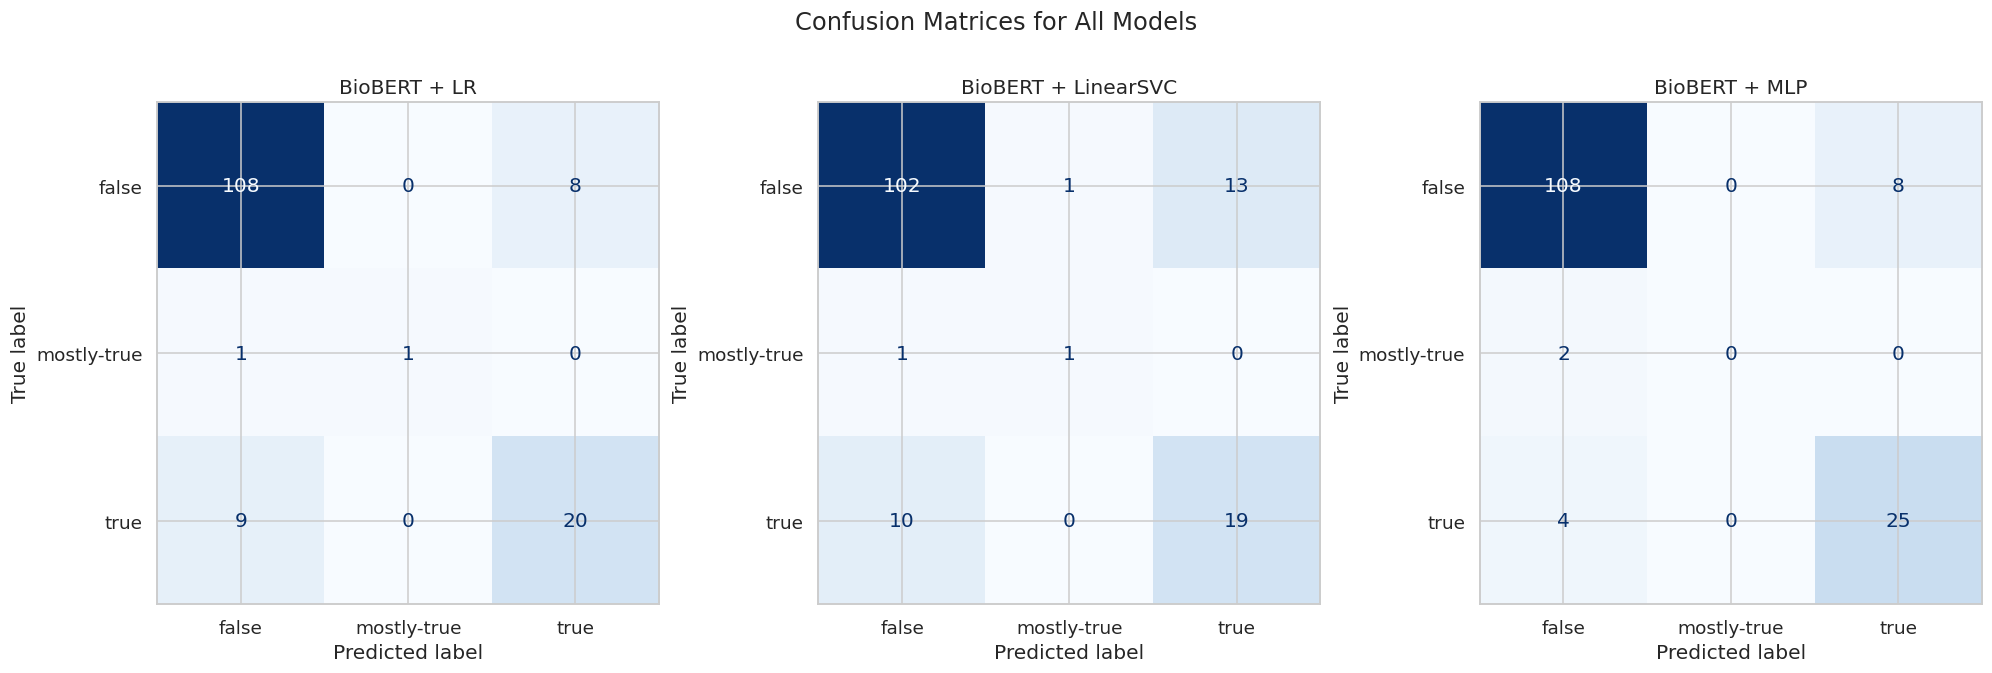

Classification report for BioBERT + LR:
              precision    recall  f1-score   support

       false       0.92      0.93      0.92       116
 mostly-true       1.00      0.50      0.67         2
        true       0.71      0.69      0.70        29

    accuracy                           0.88       147
   macro avg       0.88      0.71      0.76       147
weighted avg       0.88      0.88      0.88       147

--------------------------------------------------------------------------------
Classification report for BioBERT + LinearSVC:
              precision    recall  f1-score   support

       false       0.90      0.88      0.89       116
 mostly-true       0.50      0.50      0.50         2
        true       0.59      0.66      0.62        29

    accuracy                           0.83       147
   macro avg       0.67      0.68      0.67       147
weighted avg       0.84      0.83      0.83       147

----------------------------------------------------------------------

In [48]:
models = list(biobert_models.items())
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6), constrained_layout=True)

for ax, (name, clf) in zip(axes, models):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices for All Models', y=1.02)
plt.show()

for name, clf in models:
    y_pred = clf.predict(X_test)
    print(f'Classification report for {name}:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print('-' * 80)

In [55]:

print('=' * 100)

# Header
header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"CV F1±σ":>13}'
print(header)
print('-' * 80)

for name, res in cv_results_bb.items():
    cv = cv_results_bb.get(name)
    if cv is not None and 'test_f1_macro' in cv:
        cv_f1_mean = cv['test_f1_macro'].mean()
        cv_f1_std = cv['test_f1_macro'].std()
    else:
        cv_f1_mean = float('nan')
        cv_f1_std = float('nan')

    acc_mean = res['test_accuracy'].mean()
    prec_mean = res['test_precision_macro'].mean()
    rec_mean = res['test_recall_macro'].mean()
    f1_mean = res['test_f1_macro'].mean()

    row = (
        f'{name:<30} '
        f'{acc_mean:>7.3f} '
        f'{prec_mean:>7.3f} '
        f'{rec_mean:>7.3f} '
        f'{f1_mean:>7.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 100)
print()

Modèle                             Acc    Prec  Recall  F1-mac       CV F1±σ
--------------------------------------------------------------------------------
BioBERT + LR                     0.850   0.690   0.657   0.666  0.666±0.139
BioBERT + LinearSVC              0.832   0.660   0.617   0.624  0.624±0.095
BioBERT + MLP                    0.873   0.620   0.580   0.588  0.588±0.111

